In [1]:
using JLD2
using Plots



In [2]:

data_dir = joinpath(@__DIR__, "data")

all_sim_data = Dict{Float64, Dict{String, Any}}()

if isdir(data_dir)
    data_files = filter(f -> startswith(f, "data_eps_sigma_") && endswith(f, ".jld2"), readdir(data_dir))
    
    if isempty(data_files)
        println("No data files found in $data_dir.")
    else
        for file in data_files
            filepath = joinpath(data_dir, file)
            
            try
                file_data = load(filepath)
                
                if haskey(file_data, "sigma")
                    σ_val = file_data["sigma"]
                    all_sim_data[σ_val] = file_data
                    println("Successfully loaded data for σ = $σ_val from $file")
                else
                    println("Warning: 'sigma' key not found in $file. Skipping.")
                end
            catch e
                # If the file is corrupted/empty (e.g., EOFError), catch it and skip
                println("ERROR skipping corrupted file: $file")
                println("   -> Details: $e")
            end
        end
        println("\nDone! Total valid configurations loaded: $(length(all_sim_data))")
    end
else
    println("Directory $data_dir does not exist. Please check your path.")
end



Successfully loaded data for σ = 0.1 from data_eps_sigma_1.0e-01.jld2
Successfully loaded data for σ = 0.01 from data_eps_sigma_1.0e-02.jld2
Successfully loaded data for σ = 0.001 from data_eps_sigma_1.0e-03.jld2
Successfully loaded data for σ = 1.0e-5 from data_eps_sigma_1.0e-05.jld2
Successfully loaded data for σ = 0.012 from data_eps_sigma_1.2e-02.jld2
Successfully loaded data for σ = 0.014 from data_eps_sigma_1.4e-02.jld2
Successfully loaded data for σ = 0.016 from data_eps_sigma_1.6e-02.jld2
Successfully loaded data for σ = 0.018 from data_eps_sigma_1.8e-02.jld2
Successfully loaded data for σ = 0.02 from data_eps_sigma_2.0e-02.jld2
Successfully loaded data for σ = 0.002 from data_eps_sigma_2.0e-03.jld2
Successfully loaded data for σ = 2.0e-7 from data_eps_sigma_2.0e-07.jld2
Successfully loaded data for σ = 0.022 from data_eps_sigma_2.2e-02.jld2
Successfully loaded data for σ = 0.024 from data_eps_sigma_2.4e-02.jld2
Successfully loaded data for σ = 2.4e-6 from data_eps_sigma_2.4e-0

┌ Warning: Opening file with JLD2.MmapIO failed, falling back to IOStream
└ @ JLD2 C:\Users\Ethan\.julia\packages\JLD2\hbsZG\src\JLD2.jl:162
Error encountered while load FileIO.File{FileIO.DataFormat{:JLD2}, String}("c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_breaking_VN\\data\\data_eps_sigma_3.0e-06.jld2").

Fatal error:


ERROR skipping corrupted file: data_eps_sigma_3.0e-06.jld2
   -> Details: CapturedException(EOFError(), Any[(jldopen(fname::String, wr::Bool, create::Bool, truncate::Bool, iotype::Type{JLD2.MmapIO}; fallback::Type{IOStream}, compress::Bool, mmaparrays::Bool, typemap::Function, parallel_read::Bool, plain::Bool) at JLD2.jl:242, 1), (jldopen at JLD2.jl:174 [inlined], 1), (#jldopen#23 at JLD2.jl:297 [inlined], 1), (jldopen(fname::String, mode::String) at JLD2.jl:290, 1), (fileio_load(f::FileIO.File{FileIO.DataFormat{:JLD2}, String}; nested::Bool, kwargs::Base.Pairs{Symbol, Union{}, Tuple{}, @NamedTuple{}}) at fileio.jl:38, 1), (fileio_load(f::FileIO.File{FileIO.DataFormat{:JLD2}, String}) at fileio.jl:37, 1), (#invokelatest#2 at essentials.jl:1055 [inlined], 1), (invokelatest at essentials.jl:1052 [inlined], 1), (action(::Symbol, ::Vector{Union{Base.PkgId, Module}}, ::FileIO.Formatted; options::Base.Pairs{Symbol, Union{}, Tuple{}, @NamedTuple{}}) at loadsave.jl:219, 1), (action at loadsave

┌ Warning: Opening file with JLD2.MmapIO failed, falling back to IOStream
└ @ JLD2 C:\Users\Ethan\.julia\packages\JLD2\hbsZG\src\JLD2.jl:162
Error encountered while load FileIO.File{FileIO.DataFormat{:JLD2}, String}("c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_breaking_VN\\data\\data_eps_sigma_9.6e-06.jld2").

Fatal error:



Done! Total valid configurations loaded: 88


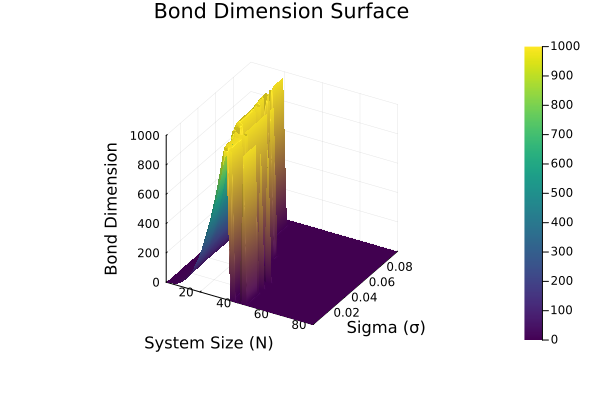

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_breaking_VN\\images\\bond_dimension_surface.pdf"

In [3]:

sorted_sigmas = sort(collect(keys(all_sim_data)))
# sorted_sigmas = sorted_sigmas[1:13]  
sorted_sigmas = sorted_sigmas[40:end]


N_vals = all_sim_data[sorted_sigmas[1]]["N_range"]
Z_bond_dims = zeros(length(sorted_sigmas), length(N_vals))


for (i, σ) in enumerate(sorted_sigmas)
    Z_bond_dims[i, :] = all_sim_data[σ]["avg_arr"]
end

p_surface = surface(
    N_vals, 
    sorted_sigmas, 
    Z_bond_dims,
    title = "Bond Dimension Surface",
    xlabel = "System Size (N)",
    ylabel = "Sigma (σ)",
    zlabel = "Bond Dimension",
    camera = (30, 30),
    color = :viridis, 
    colorbar = true,
    margin = 5Plots.mm
)

display(p_surface)
savefig(p_surface, joinpath("images", "bond_dimension_surface.pdf"))

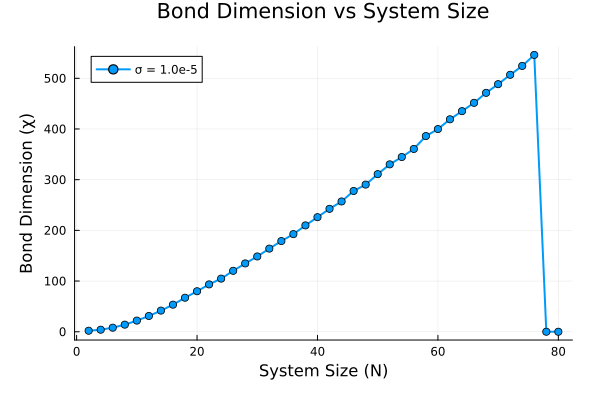

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_breaking_VN\\images\\bond_dim_specific_sigmas_2d.png"

In [8]:

target_sigmas = [0.0, 1e-7, 1e-6, 1e-5]

p_2d = plot(
    title = "Bond Dimension vs System Size",
    xlabel = "System Size (N)",
    ylabel = "Bond Dimension (χ)",
    legend = :topleft,    
    margin = 5Plots.mm
)

for σ in target_sigmas
    if haskey(all_sim_data, σ)
        data = all_sim_data[σ]
        
        N_vals = data["N_range"]
        bond_dims = data["avg_arr"]
        

        plot!(p_2d, N_vals, bond_dims, 
              label = "σ = $(σ)", 
              marker = :circle, 
              linewidth = 2)
    else
        println("Warning: Data for σ = $σ is missing or was corrupted and skipped earlier.")
    end
end

display(p_2d)
savefig(p_2d, joinpath("images", "bond_dim_specific_sigmas_2d.png"))

In [5]:
function analyse_post_dmrg_cutoff(spectra_avg::Matrix{Float64}, N_range::Vector{Int}, new_cutoff::Float64)
    num_N = length(N_range)
    effective_bond_dims = zeros(Int, num_N)
    discarded_weights = zeros(Float64, num_N)
    
    for i in 1:num_N
        # Get the averaged spectrum for this N and sort in descending order
        p = sort(spectra_avg[i, :], rev=true)
        
        chi = 0
        kept_weight = 0.0
        
        # Calculate how many Schmidt values we need to keep
        for (idx, prob) in enumerate(p)
            kept_weight += prob
            chi = idx
            
            # The state lost is the sum of the remaining probabilities
            state_lost = 1.0 - kept_weight
            
            # If the state lost is within our acceptable new cutoff, we stop
            if state_lost <= new_cutoff
                break
            end
        end
        
        effective_bond_dims[i] = chi
        # Floating point arithmetic can sometimes leave tiny negative numbers, so we bound it at 0.0
        discarded_weights[i] = max(0.0, 1.0 - kept_weight) 
    end
    
    return effective_bond_dims, discarded_weights
end

analyse_post_dmrg_cutoff (generic function with 1 method)

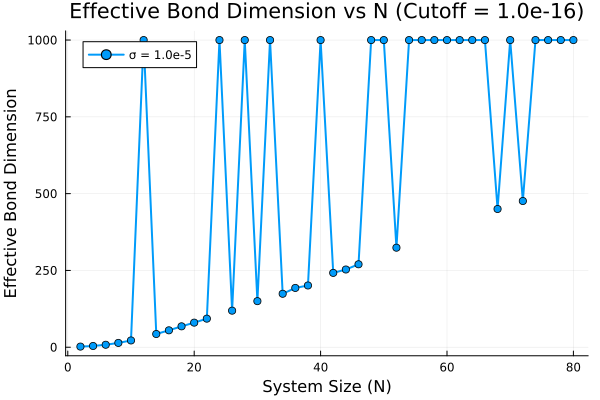

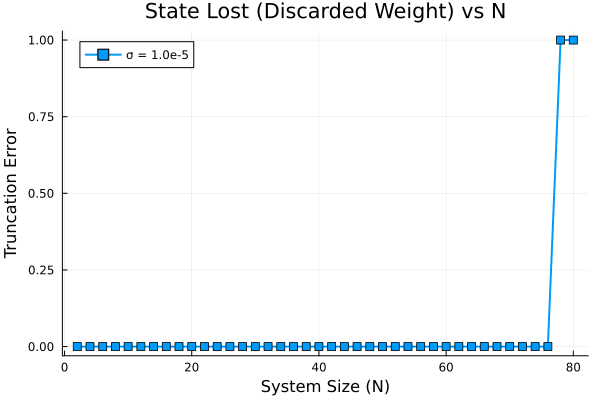

In [11]:
new_cutoff = 1e-16

sigmas_to_plot = [0.0, 1e-7, 1e-6, 1e-5] 

min_N = 2
max_N = 80

p_eff_dim = plot(title="Effective Bond Dimension vs N (Cutoff = $new_cutoff)", 
                 xlabel="System Size (N)", ylabel="Effective Bond Dimension", legend=:topleft)

p_state_lost = plot(title="State Lost (Discarded Weight) vs N", 
                    xlabel="System Size (N)", ylabel="Truncation Error", legend=:topleft)

for σ in sigmas_to_plot
    if haskey(all_sim_data, σ)
        data = all_sim_data[σ]
        N_vals = data["N_range"]
        spectra_avg = data["spectra_avg"]
        
        eff_dims, state_lost = analyse_post_dmrg_cutoff(spectra_avg, N_vals, new_cutoff)
        
        valid_indices = findall(N -> min_N <= N <= max_N, N_vals)
        
        N_plot = N_vals[valid_indices]
        eff_dims_plot = eff_dims[valid_indices]
        state_lost_plot = state_lost[valid_indices]
        
        plot!(p_eff_dim, N_plot, eff_dims_plot, label="σ = $σ", marker=:circle, linewidth=2)
        plot!(p_state_lost, N_plot, state_lost_plot, label="σ = $σ", marker=:square, linewidth=2)
    else
        println("Warning: Data for σ = $σ not found in all_sim_data. Skipping...")
    end
end

display(p_eff_dim)
display(p_state_lost)

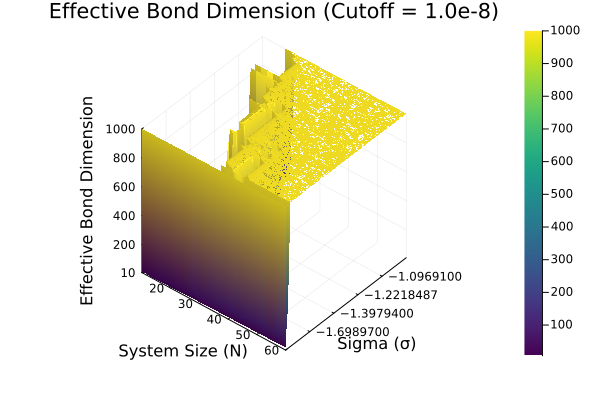

In [7]:
new_cutoff = 1e-8 
min_N = 10
max_N = 60


all_sigmas = sort(collect(keys(all_sim_data)))
# all_sigmas = [0.0, 1e-5, 1e-4, 1e-3, 0.01, 0.1]

first_sigma_data = all_sim_data[all_sigmas[1]]
N_vals_all = first_sigma_data["N_range"]

valid_indices = findall(N -> min_N <= N <= max_N, N_vals_all)
N_plot = N_vals_all[valid_indices]


Z_eff_dim = zeros(Float64, length(all_sigmas), length(N_plot))

for (i, σ) in enumerate(all_sigmas)
    data = all_sim_data[σ]
    spectra_avg = data["spectra_avg"]
    
    # Calculate effective dimensions for this specific sigma
    eff_dims, _ = analyse_post_dmrg_cutoff(spectra_avg, N_vals_all, new_cutoff)
    
    # Filter to the chosen N range and store the row in the Z matrix
    Z_eff_dim[i, :] = eff_dims[valid_indices]
end

p_surface = surface(N_plot, all_sigmas, Z_eff_dim, 
                    title="Effective Bond Dimension (Cutoff = $new_cutoff)",
                    xlabel="System Size (N)", 
                    ylabel="Sigma (σ)", 
                    zlabel="Effective Bond Dimension",
                    yaxis = log10,
                    camera=(40, 40),      
                    color=:viridis,       
                    colorbar=true,
                    right_margin=5Plots.mm) 

display(p_surface)